### درونیابی لاگرانژ و اسپلاین

In [1]:
import numpy as np
from scipy.interpolate import lagrange, CubicSpline

x = np.array([1, 2, 3, 4, 5, 6], dtype=float)
y = np.array([1, 3, 5, 8, 5, 2], dtype=float)

poly_lagrange = lagrange(x, y)
print(poly_lagrange)

cs_spline = CubicSpline(x, y, bc_type='natural')
print(cs_spline.x)
print(cs_spline.c)

       5         4         3         2
0.175 x - 2.958 x + 18.38 x - 52.04 x + 68.45 x - 31
[1. 2. 3. 4. 5. 6.]
[[-0.18660287  0.93301435 -2.54545455  2.24880383 -0.44976077]
 [ 0.         -0.55980861  2.23923445 -5.39712919  1.3492823 ]
 [ 2.18660287  1.62679426  3.3062201   0.14832536 -3.89952153]
 [ 1.          3.          5.          8.          5.        ]]


### خواندن داده‌ها و ترسیم نمودارها

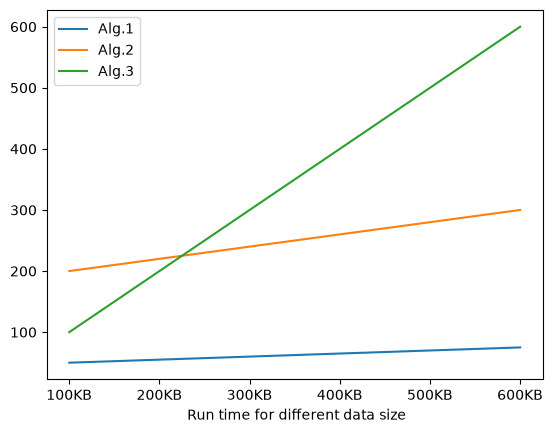

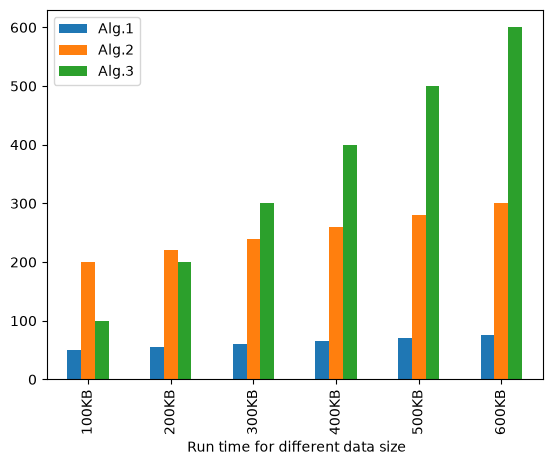

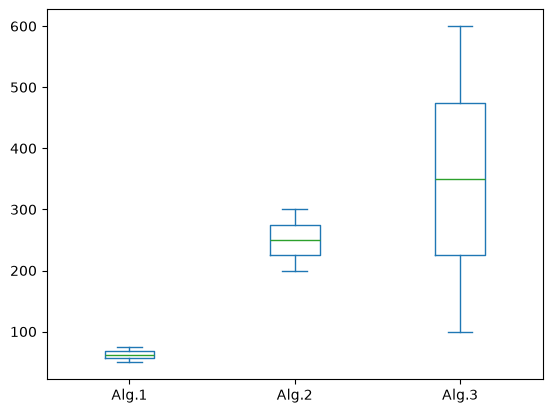

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

path = r'C:\Users\USER\Desktop\Narmafzar riazi\پروژه 3.xlsx'
df = pd.read_excel(path)
df = df.dropna(how='all')

df.plot(kind='line', x=df.columns[0])
plt.show()

df.plot(kind='bar', x=df.columns[0])
plt.show()

df.iloc[:, 1:].plot(kind='box')
plt.show()

###  اضافه کردن داده جدید

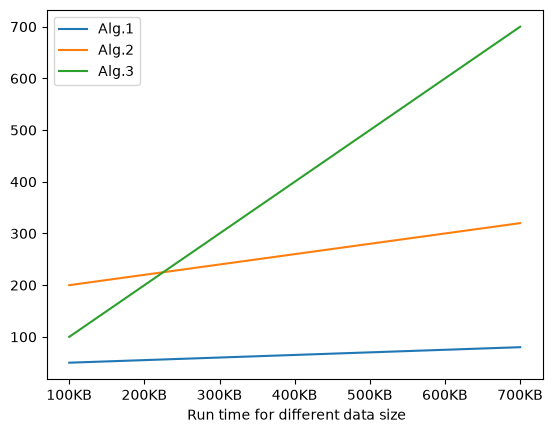

In [3]:
new_data = {df.columns[0]: '700KB', 'Alg.1': 80, 'Alg.2': 320, 'Alg.3': 700}
df = pd.concat([df, pd.DataFrame([new_data])], ignore_index=True)

df.plot(kind='line', x=df.columns[0])
plt.show()

### محاسبه میانگین

In [4]:
df_filtered = df[df[df.columns[0]].astype(str).str.replace('KB', '').astype(float).between(100, 600)]
avg_alg2 = df_filtered[df.columns[2]].mean()
print(avg_alg2)

250.0


### انتگرال‌گیری عددی سیمپسون و ذوزنقه

In [5]:
import numpy as np
from scipy.integrate import simpson, trapezoid

x_int = np.linspace(0, 1, 101)
y_int = np.exp(x_int**2)

res_trapezoid = trapezoid(y_int, x_int)
res_simpson = simpson(y_int, x_int)

print(res_trapezoid)
print(res_simpson)

1.4626970498492724
1.462651748926934


###  انتگرال‌گیری گاوسی

In [6]:
import numpy as np
from scipy.integrate import quad

def f(x):
    return np.exp(x**2)

res_gaussian, error = quad(f, 0, 1)
print(res_gaussian)
print(error)

1.4626517459071815
1.623869645314337e-14
